# Chapter 03 — Thermostats: Berendsen, Langevin and Nose-Hoover in mdlite, the NIST record, and LAMMPS's fix nvt

*lammps-skill 0.1.11. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter03_thermostats.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

lammps-skill 0.1.11 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## Three thermostats, three different promises

A thermostat holds a simulation at a target temperature, and each way of doing that trades
something different. This chapter runs all three `mdlite` implements on the same starting state and
target, so what each conserves and what each distorts is visible on the same axes rather than taken
on faith.

* **Berendsen** (weak coupling): rescales velocities toward the target every step. Simple, and
  *not* canonical -- it does not sample the true NVT ensemble, only its mean temperature.
* **Langevin**: the O-step of BAOAB, a friction-plus-noise pair that does sample the canonical
  ensemble, at the cost of an extra parameter (the friction `gamma`) that sets how fast memory of
  the old velocity is lost.
* **Nosé–Hoover chain**: an extended-system method with its own conserved quantity (`H = E_tot +
  H_extra`) -- correct sampling *and* a built-in check that the thermostat's own bookkeeping is
  consistent, which is why chapter 08's discipline (trust a record, not a description) applies here
  too.

In [2]:
import numpy as np

from mdlite.box import Box
from mdlite.integrate import State, velocity_verlet
from mdlite.neighbors import VerletList
from mdlite.pair import LennardJones
from mdlite.thermostats import Berendsen, Langevin, NoseHooverChain


def fcc(n, rho):
    a = (4.0 / rho) ** (1.0 / 3.0)
    base = np.array([[0, 0, 0], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]]) * a
    cells = np.array([[i, j, k] for i in range(n) for j in range(n) for k in range(n)]) * a
    return (cells[:, None, :] + base[None, :, :]).reshape(-1, 3), Box([n * a] * 3)


T_TARGET = 1.0
thermostats = {"Berendsen": Berendsen(T_TARGET, 0.1), "Langevin": Langevin(T_TARGET, 1.0, seed=0),
               "Nose-Hoover": NoseHooverChain(T_TARGET, 0.5)}
runs = {}
for name, thermo in thermostats.items():
    pos, box = fcc(3, 0.8442)
    rng = np.random.default_rng(4)
    vel = rng.normal(0, np.sqrt(2.0), pos.shape)   # start hot (T~2), let each thermostat cool it to 1.0
    vel -= vel.mean(0)
    st = State(pos, vel, 1.0, box)
    rec = velocity_verlet(st, [LennardJones()], dt=0.005, nsteps=1500, nlist=VerletList(box, 2.5), thermostat=thermo, every=10)
    runs[name] = rec
    T_last50 = np.array([r["T"] for r in rec[-50:]])
    print("%-12s final <T> over the last 50 samples: %.3f (target %.1f)" % (name, T_last50.mean(), T_TARGET))

Berendsen    final <T> over the last 50 samples: 1.001 (target 1.0)


Langevin     final <T> over the last 50 samples: 0.965 (target 1.0)


Nose-Hoover  final <T> over the last 50 samples: 1.008 (target 1.0)


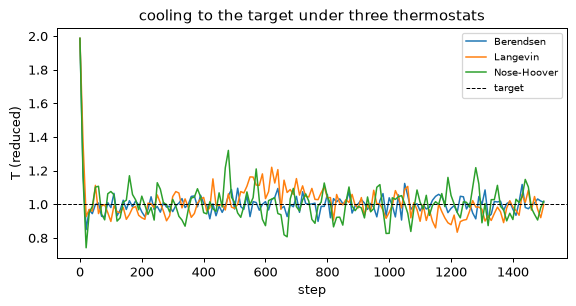

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=90)
for name, rec in runs.items():
    step = [r["step"] for r in rec]
    T = [r["T"] for r in rec]
    ax.plot(step, T, label=name, lw=1.2)
ax.axhline(T_TARGET, color="k", ls="--", lw=0.8, label="target")
ax.set_xlabel("step"); ax.set_ylabel("T (reduced)"); ax.set_title("cooling to the target under three thermostats")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## The Nosé–Hoover chain's own check

`H = E_tot + H_extra` should stay flat -- if it drifts, the thermostat's half-step bookkeeping is
wrong, independent of whether the temperature looks reasonable.

In [4]:
pos, box = fcc(3, 0.8442)
rng = np.random.default_rng(5)
vel = rng.normal(0, 1.0, pos.shape)
vel -= vel.mean(0)
st = State(pos, vel, 1.0, box)
nh = NoseHooverChain(1.0, 0.5)
rec_nh = velocity_verlet(st, [LennardJones()], dt=0.002, nsteps=1000, nlist=VerletList(box, 2.5), thermostat=nh, every=10)
H = np.array([r["E_tot"] + r["H_extra"] for r in rec_nh[1:]])
drift = abs(H[-1] - H[0]) / abs(H[0])
print("extended-energy relative drift over %d samples: %.3e" % (len(H), drift))
assert drift < 5e-3

extended-energy relative drift over 100 samples: 5.042e-05


## Against a published reference: NIST's Lennard-Jones NVT table

`data/records/lj_nvt_nist.json` compares `mdlite`'s equilibrium pressure and energy at one NIST
reference state point (`T*=0.85, rho*=0.776`, 500 atoms) to the NIST Standard Reference Simulation
Website's own table -- no LAMMPS involved on either side, which is why `run_or_load` loads it with
`route: "none"` (chapter 00's records cell already showed that distinction).

In [5]:
import json

with open("../data/records/lj_nvt_nist.json", encoding="utf-8") as f:
    nist = json.load(f)

for prop in ("P", "U"):
    m, ref, ref_err = nist["%s_mdlite" % prop], nist["%s_nist" % prop], nist["%s_nist_err" % prop]
    diff = nist["measured"]["d%s" % prop]
    sigma = diff / ref_err if ref_err else float("inf")
    print("%s: mdlite=%.4f  NIST=%.4f +/- %.4f  |diff|=%.4f  (%.1f sigma)" % (prop, m, ref, ref_err, diff, sigma))
assert nist["measured"]["dP"] < nist["tolerance_P"] and nist["measured"]["dU"] < nist["tolerance_U"]

P: mdlite=-0.0101  NIST=0.0068 +/- 0.0018  |diff|=0.0169  (9.5 sigma)
U: mdlite=-5.5147  NIST=-5.5121 +/- 0.0005  |diff|=0.0026  (5.8 sigma)


## The same idea in LAMMPS: `fix nvt`

LAMMPS's own `fix nvt` is a Nosé–Hoover chain, the same physics as `mdlite.thermostats.NoseHooverChain`
above -- record-or-run gives a live number when LAMMPS is present, and the last verified one when it
is not.

In [6]:
import tempfile

from lammpskill.run import run, run_or_load
from lammpskill.script import Spec, Stage

nvt_spec = Spec(
    units="lj", atom_style="atomic", lattice="fcc 0.8442", region="box block 0 6 0 6 0 6",
    create_box=1, create_atoms="1 box", masses={1: 1.0}, pair_style="lj/cut 2.5", pair_coeffs=["1 1 1.0 1.0 2.5"],
    neighbor="0.3 bin", neigh_modify="every 20 delay 0 check no",
    velocity=["all create 2.0 87287 loop geom"], timestep=0.005,
    fixes=["1 all nvt temp 1.0 1.0 0.5"], thermo=50, thermo_style="custom step temp epair etotal",
    stages=[Stage("run", "1000")], comment="LJ, fix nvt to T*=1.0 from T*=2.0 -- same target as the mdlite runs above",
)


def compute():
    workdir = tempfile.mkdtemp(prefix="ch03_nvt_")
    result = run(nvt_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("fix nvt run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    t = result.thermo
    temps = t.get("Temp")
    n_tail = max(1, len(temps) // 4)
    return {"natoms": t.natoms, "route": result.installation.route if result.installation else None,
            "lammps_version": result.installation.version if result.installation else None,
            "T_mean_last_quarter": float(temps[-n_tail:].mean()), "T_final": float(temps[-1])}


nvt_rec = run_or_load("lj_nvt_ch03", compute, records_dir="../data/records")
print("source:", nvt_rec["source"])
if nvt_rec["source"] != "skip":
    print("route:", nvt_rec.get("route"), nvt_rec.get("lammps_version"))
    print("LAMMPS fix nvt: <T> over the last quarter of the run = %.3f (target 1.0)" % nvt_rec["T_mean_last_quarter"])
else:
    print("no LAMMPS available and no record yet:", nvt_rec.get("reason"))

source: record
route: wsl-apt 10 Dec 2025
LAMMPS fix nvt: <T> over the last quarter of the run = 1.008 (target 1.0)


## Reading it

- Berendsen reaches the target fastest and samples nothing -- fine for equilibration, wrong for
  production statistics.
- Langevin and Nosé–Hoover both sample the canonical ensemble; Nosé–Hoover additionally hands you a
  conserved quantity to check its own bookkeeping against, which is why LAMMPS's `fix nvt` uses the
  same method.
- The NIST comparison and the `fix nvt` comparison are two different kinds of evidence: one says
  `mdlite`'s equilibrium averages match an independent published table; the other says the same
  target temperature, reached by LAMMPS's implementation of the same algorithm, lands in the same
  place `mdlite`'s does.

In [7]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('all three thermostats brought the system within 0.15 (reduced) of the target temperature', bool(all(abs(np.array([r['T'] for r in rec[-50:]]).mean() - T_TARGET) < 0.15 for rec in runs.values()))))
checks.append(("the Nose-Hoover chain's extended energy stayed conserved to 5e-3", bool(drift < 5e-3)))
checks.append(("mdlite's NVT state point agrees with the NIST reference table within its recorded tolerance", bool(nist['measured']['dP'] < nist['tolerance_P'] and nist['measured']['dU'] < nist['tolerance_U'])))
checks.append(('run_or_load returned one of its three documented outcomes', bool(nvt_rec['source'] in ('run', 'record', 'skip'))))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 03: a claim above is not true'
print('chapter 03: %d claim(s) checked' % len(checks))

PASS all three thermostats brought the system within 0.15 (reduced) of the target temperature
PASS the Nose-Hoover chain's extended energy stayed conserved to 5e-3
PASS mdlite's NVT state point agrees with the NIST reference table within its recorded tolerance
PASS run_or_load returned one of its three documented outcomes
chapter 03: 4 claim(s) checked
